# PHYS 332 - Numerical Techniques for the Sciences II
## Homework 01: Ordinary Differential Equations
### Problem 2 -  Fixed-step integrators
---
Name: *Ethan Duarte*

Onyen: *deth*

Cell for *Problem 2* is below.

RMS Error (10): 0.024947645803366926
RMS Error (100): 0.0062297557879828535
RMS Error (1000): 0.0036147083370967263
RMS Error (10000): 0.0005180650866912107


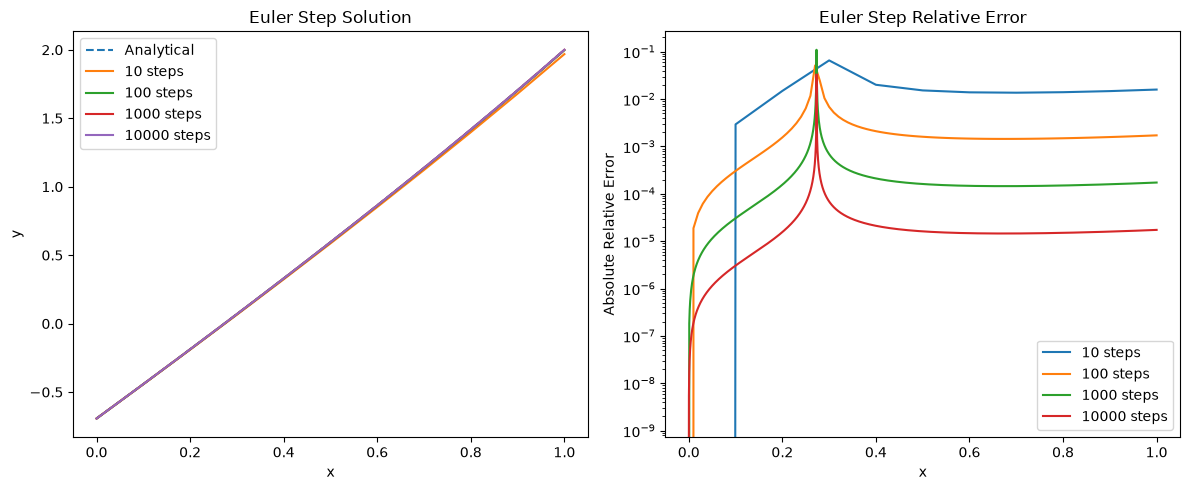

RMS Error (10): 0.0005899753597765542
RMS Error (100): 1.4082989657572357e-05
RMS Error (1000): 8.1132444648148e-07
RMS Error (10000): 1.1627173716619727e-08


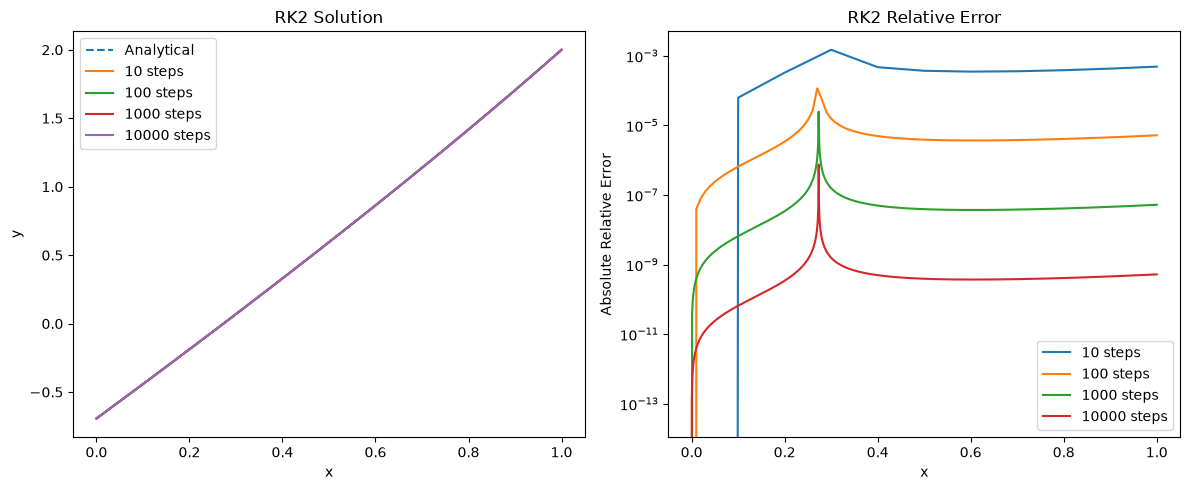

RMS Error (10): 2.81018740501649e-08
RMS Error (100): 6.312381174484316e-12
RMS Error (1000): 2.842055080172835e-14
RMS Error (10000): 2.751241873960466e-14


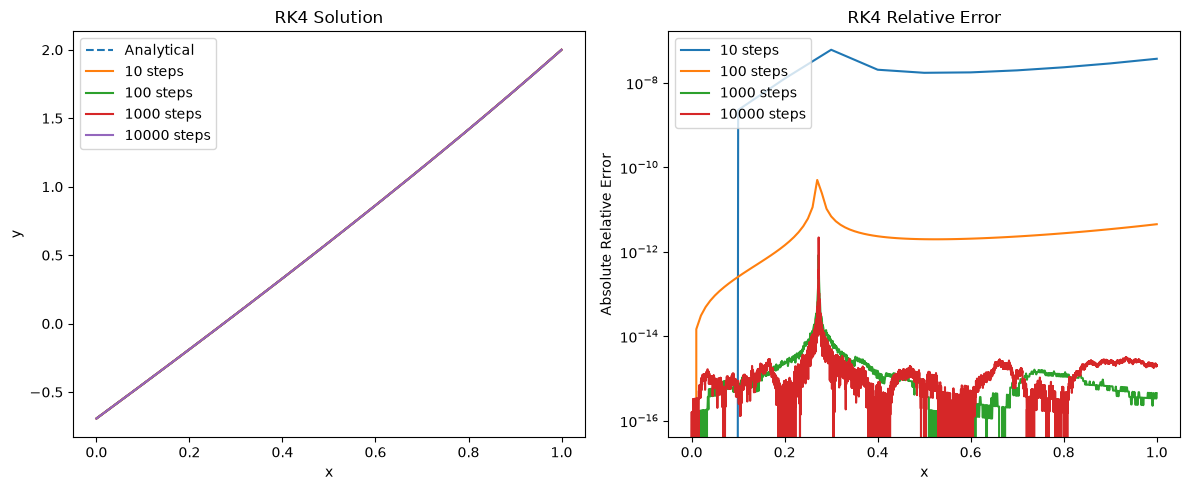

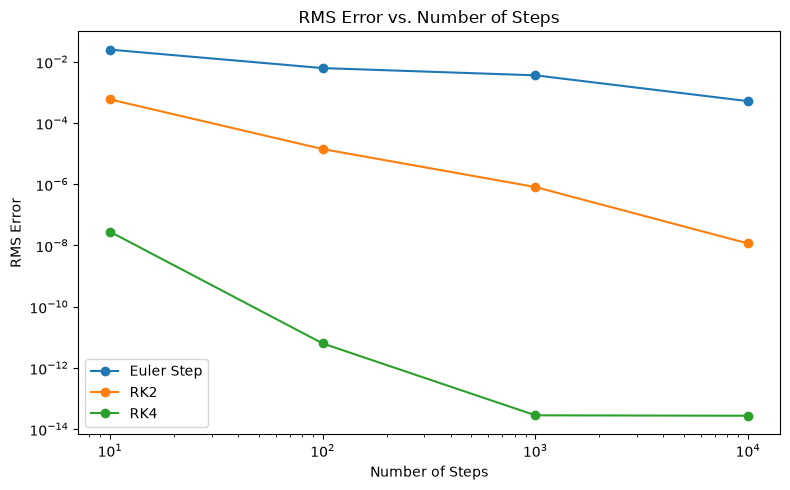

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def eulerstep(y,f,x,h):

    """
    Advances solution by a single Euler step
    
    PARAMETERS:
    input:
        y -- initial value, scalar;
        f -- function (RHS of ODE);
        x -- starting x.
        h -- stepsize

    RETURNS:
        updated result

        See the assignment sheet for additional details about these
        function parameters.
    """

    ynew = y + f(x,y)*h
    
    return ynew


def rk2step(y,f,x,h):

    """
    Advances solution by a single RK2 step
    
    PARAMETERS:
    input:
        y -- initial value, scalar;
        f -- function (RHS of ODE);
        x -- starting x.
        h -- stepsize

    RETURNS:
        updated result

        See the assignment sheet for additional details about these
        function parameters.
    """

    ## Your code goes here
    k1 = h * f(x,y)
    k2 = h * f(x + h/2, y + k1/2)
    ynew = y + k2
    
    return ynew


def rk4step(y,f,x,h):
    """
    Advances solution by a single RK4 step
    
    PARAMETERS:
    input:
        y -- initial value, scalar;
        f -- function (RHS of ODE);
        x -- starting x.
        h -- stepsize

    RETURNS:
        updated result

        See the assignment sheet for additional details about these
        function parameters.
    """

    ## Your code goes here
    k1 = h * f(x, y)
    k2 = h * f(x + h/2, y + k1 / 2)
    k3 = h * f(x + h / 2, y + k2 / 2)
    k4 = h * f(x + h, y + k3)
    ynew = y + (k1 + 2 * k2 + 2 * k3 + k4) / 6
    
    return ynew


def ode_fixedstep(nstep,f,x0,y0,x1,iinteg):

    """
    Solves an ordinary differential equation
    using fixed step size.

    PARAMETERS:
    input:
        nstep  : number of steps
        f      : inline function (RHS of ODE)
        x0     : starting x.
        y0     : starting y (scalar).
        x1     : end x.
        iinteg : integrator: 0: Euler
                            1: Runge-Kutta 2nd order
                            2: Runge-Kutta 4th order
    output:
        x      : positions of n+1 steps
        y      : (nstep+1,1) vector of resulting y's
    
     comment  : Determine dx from the given stepsize and the integration
                boundaries. You will have to provide the integrators
                through functions eulerstep, rk2step, rk4step.
                Each of them does just one single step.

    """

    h = (x1 - x0) / nstep
    X = np.linspace(x0, x1, nstep + 1)
    Y = [y0]
    methods = [eulerstep, rk2step, rk4step]
    for i in range(len(X) - 1):
        Y = np.append(Y, methods[iinteg](Y[i], f, X[i], h)
)

    return X, Y

def func(x, y):
    return np.exp(y - 2 * x) + 2

def anSol(x):
    return 2 * x - np.log(np.abs(2 - x))

X = np.linspace(0, 1, 1001)

#Plotting Stuff so it's pretty <3

steps = [10, 100, 1000, 10000]
integrators = [
    (0, "Euler Step"),
    (1, "RK2"),
    (2, "RK4")
]

rms_results = []

for method, name in integrators:

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Analytical solution
    ax[0].plot(X, anSol(X), ls="--", label="Analytical")

    rms_errors = []

    for n in steps:

        x_num, y_num = ode_fixedstep(n, func, 0, -np.log(2), 1, method)

        error = (y_num - anSol(x_num)) / anSol(x_num)

        rms_error = np.sqrt(np.sum(error ** 2 / n))

        rms_errors.append(rms_error)

        print(f"RMS Error ({n}): {rms_error}")

        ax[0].plot(x_num, y_num, label=f"{n} steps")
        ax[1].semilogy(x_num, np.abs(error), label=f"{n} steps")

    rms_results.append((name, rms_errors))

    ax[0].set_title(f"{name} Solution")
    ax[1].set_title(f"{name} Relative Error")

    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y")

    ax[1].set_xlabel("x")
    ax[1].set_ylabel("Absolute Relative Error")

    ax[0].legend()
    ax[1].legend()

    plt.tight_layout()
    plt.show()


#Plot RMS Errors

plt.figure(figsize=(8, 5))

for name, rms_errors in rms_results:

    plt.loglog(steps, rms_errors, marker="o", label=name)

plt.xlabel("Number of Steps")
plt.ylabel("RMS Error")
plt.title("RMS Error vs. Number of Steps")

plt.legend()
plt.tight_layout()
plt.show()